# Análise de Tempo, Energia e Memória do MergeSort com Pandas e Criação de Gráfico
Importando a biblioteca pandas e matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Carregando o CSV

In [2]:
df = pd.read_csv("../Resultados preliminares/10000000.csv")

# Visualizar primeiras linhas
print(df.head())

    vector_type algorithm      size  time_ms  stress  ram_kb_max  \
0      endnoise  HeapSort  10000000  4490.67     NaN       42944   
1       ordered  HeapSort  10000000  3942.80     NaN       42948   
2  random_swaps  HeapSort  10000000  4109.08     NaN       42944   
3        random  HeapSort  10000000  6796.72     NaN       42904   
4  repeated_1_5  HeapSort  10000000  3393.87     NaN       42900   

   ram_kb_media  energy_j  
0         42811  111.3100  
1         42815  150.0890  
2         42811  148.3980  
3         42771  229.0000  
4         42767   92.8636  


Filtrando apenas QuickSort

In [3]:
quick = df[df["algorithm"] == "MergeSort"]

print(quick.head())

     vector_type  algorithm      size  time_ms  stress  ram_kb_max  \
8       endnoise  MergeSort  10000000  3473.86     NaN       81844   
9        ordered  MergeSort  10000000  4117.11     NaN       81892   
10  random_swaps  MergeSort  10000000  4125.32     NaN       81788   
11        random  MergeSort  10000000  4710.01     NaN       81876   
12  repeated_1_5  MergeSort  10000000  3858.80     NaN       81848   

    ram_kb_media  energy_j  
8          48547   128.541  
9          48617   111.083  
10         48643   106.873  
11         48913   160.872  
12         48530   130.896  


Calculando média do tempo por tipo de vetor

In [4]:
quick_media = (
    quick.groupby("vector_type")["time_ms"]
    .mean()
    .sort_values()
)

print(quick_media)

vector_type
endnoise        3473.86
zigzag          3594.05
repeated_1_5    3858.80
reversed        3867.43
repeated        3915.86
ordered         4117.11
random_swaps    4125.32
random          4710.01
Name: time_ms, dtype: float64


Criando gráfico

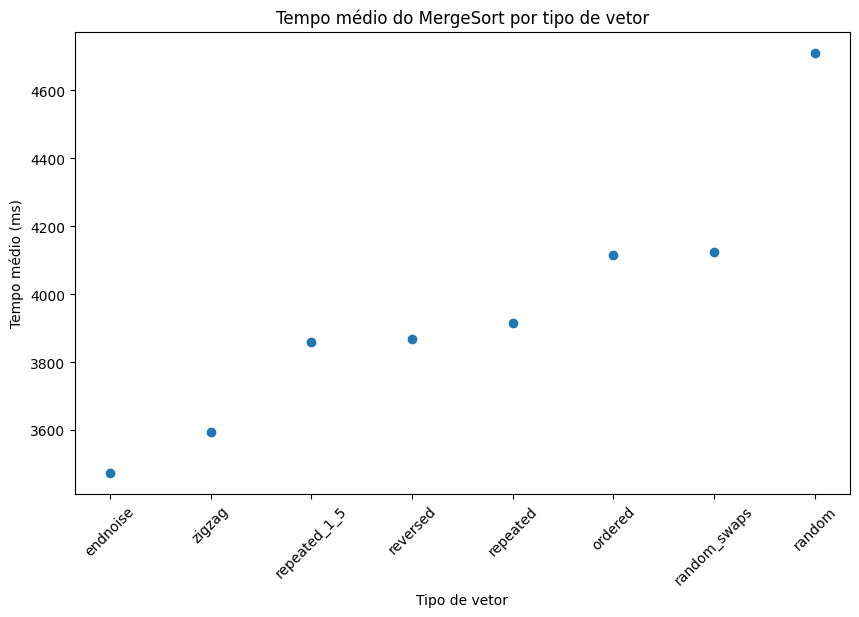

In [5]:
plt.figure(figsize=(10, 6))

plt.scatter(quick_media.index, quick_media.values)

plt.xlabel("Tipo de vetor")
plt.ylabel("Tempo médio (ms)")
plt.title("Tempo médio do MergeSort por tipo de vetor")

plt.xticks(rotation=45)

plt.show()

Consumo de energia por tipo de vetor

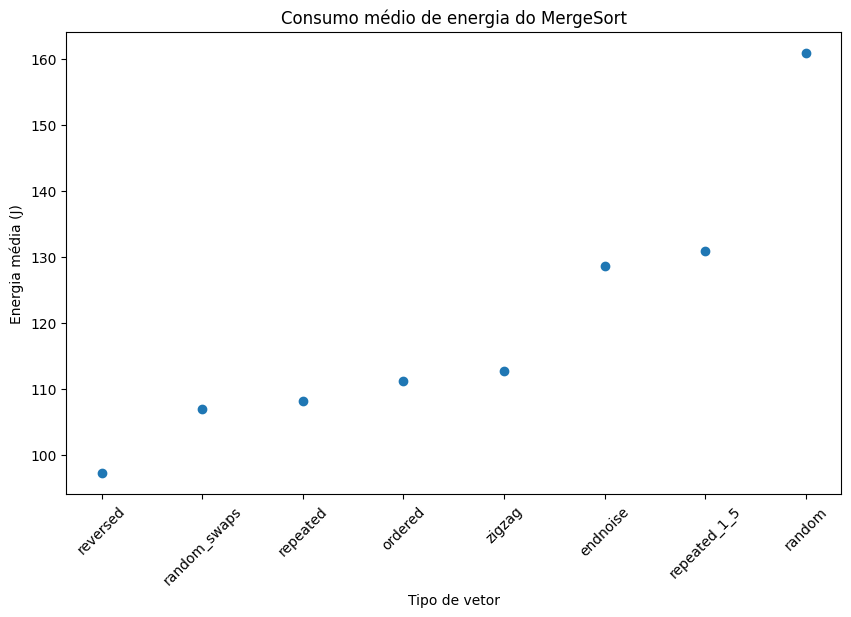

In [7]:
#Calcula Média de energia consumida por tipo de vetor para o QuickSort
energia_media = (
    quick.groupby("vector_type")["energy_j"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.scatter(energia_media.index, energia_media.values)

plt.xlabel("Tipo de vetor")
plt.ylabel("Energia média (J)")
plt.title("Consumo médio de energia do MergeSort")

plt.xticks(rotation=45)

plt.show()

Uso de RAM por tipo de vetor

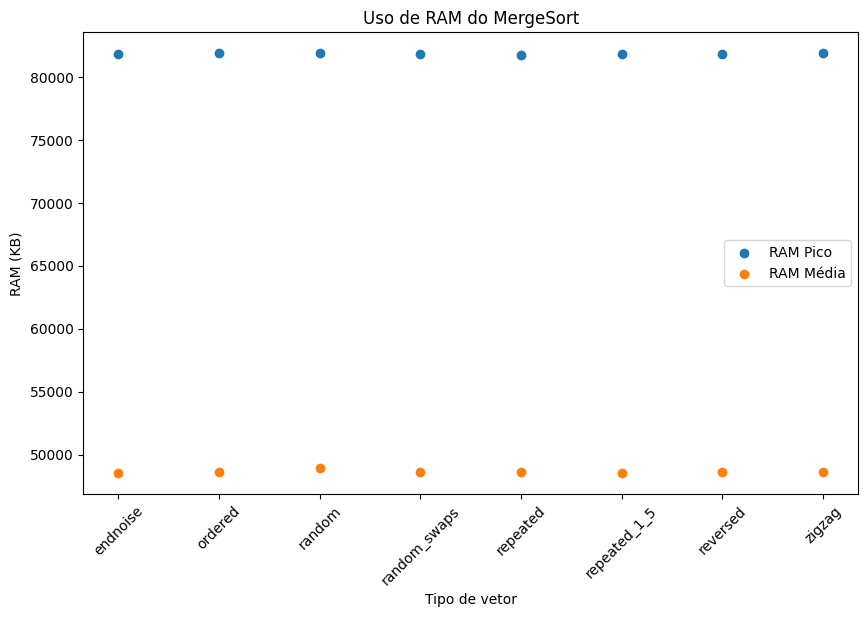

In [8]:
ram_media = (
    quick.groupby("vector_type")[["ram_kb_max", "ram_kb_media"]]
    .mean()
)

plt.figure(figsize=(10, 6))

# Pico de RAM
plt.scatter(ram_media.index, ram_media["ram_kb_max"], label="RAM Pico")

# Média de RAM
plt.scatter(ram_media.index, ram_media["ram_kb_media"], label="RAM Média")

plt.xlabel("Tipo de vetor")
plt.ylabel("RAM (KB)")
plt.title("Uso de RAM do MergeSort")

plt.legend()
plt.xticks(rotation=45)

plt.show()